# Setup (Python Libraries)

In [1]:
pip install pandas numpy matplotlib seaborn plotly

Note: you may need to restart the kernel to use updated packages.


## Load Data

In [3]:
# Dataset load
import pandas as pd
df = pd.read_csv("customer_journey.csv")

In [5]:
df.head()

,SessionID,UserID,Timestamp,PageType,DeviceType,Country,ReferralSource,TimeOnPage_seconds,ItemsInCart,Purchased
0,session_0,user_2223,20-01-25 22:53,home,Desktop,India,Social Media,55,0,0
1,session_1,user_2192,26-02-25 12:57,home,Tablet,Germany,Email,99,0,0
2,session_1,user_2192,26-02-25 12:59,product_page,Tablet,Germany,Email,121,0,0
3,session_2,user_1708,24-06-25 15:40,home,Mobile,India,Google,160,0,0
4,session_3,user_2976,11-06-25 7:21,home,Tablet,UK,Google,113,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12719 entries, 0 to 12718
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   SessionID           12719 non-null  object
 1   UserID              12719 non-null  object
 2   Timestamp           12719 non-null  object
 3   PageType            12719 non-null  object
 4   DeviceType          12719 non-null  object
 5   Country             12719 non-null  object
 6   ReferralSource      12719 non-null  object
 7   TimeOnPage_seconds  12719 non-null  int64 
 8   ItemsInCart         12719 non-null  int64 
 9   Purchased           12719 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 993.8+ KB


## Data Cleaning, Sorting

In [10]:
# Sort data
df = df.sort_values(by=['UserID', 'Timestamp'])


In [11]:
# Check missing values
df.isnull().sum()

SessionID             0
UserID                0
Timestamp             0
PageType              0
DeviceType            0
Country               0
ReferralSource        0
TimeOnPage_seconds    0
ItemsInCart           0
Purchased             0
dtype: int64

## Define Funnel Stages
 
Stage       	Condition
Home	        PageType = 'home'
Product	        PageType = 'product_page'
Cart	        PageType = 'cart'
Checkout     	PageType = 'checkout'
Purchase	    Purchased = 1

## Build Funnel

In [12]:
funnel = {}

funnel['Home'] = df[df['PageType'] == 'home']['UserID'].nunique()
funnel['Product'] = df[df['PageType'] == 'product_page']['UserID'].nunique()
funnel['Cart'] = df[df['PageType'] == 'cart']['UserID'].nunique()
funnel['Checkout'] = df[df['PageType'] == 'checkout']['UserID'].nunique()
funnel['Purchase'] = df[df['Purchased'] == 1]['UserID'].nunique()

funnel

{'Home': 1872, 'Product': 1763, 'Cart': 1084, 'Checkout': 855, 'Purchase': 792}

## Calculation

In [15]:
funnel_df = pd.DataFrame(list(funnel.items()), columns=['Stage', 'Users'])

funnel_df['Drop_%'] = funnel_df['Users'].pct_change() * -100

funnel_df

,Stage,Users,Drop_%
0,Home,1872,NaN
1,Product,1763,5.822650
2,Cart,1084,38.513897
3,Checkout,855,21.125461
4,Purchase,792,7.368421


## Funnel Visualization by plotly.express chart

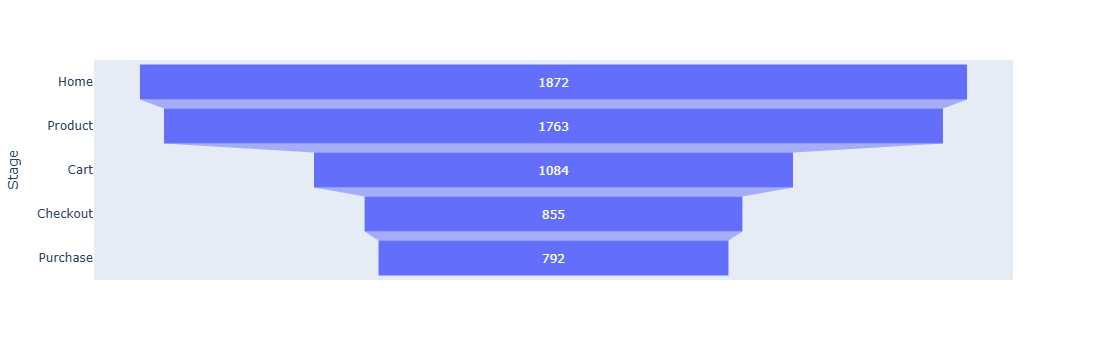

In [16]:
import plotly.express as px

fig = px.funnel(funnel_df, x='Users', y='Stage')
fig.show()

## Behavior Analysis

### 1. Split Users

In [17]:
converted_users = df[df['Purchased'] == 1]['UserID'].unique()
df['Converted'] = df['UserID'].isin(converted_users)

### 2. Compare Behavior
### Time Spent

In [18]:
df.groupby('Converted')['TimeOnPage_seconds'].mean()

Converted
False    97.347930
True     97.473106
Name: TimeOnPage_seconds, dtype: float64

#### Items in Cart

In [19]:
df.groupby('Converted')['ItemsInCart'].mean()

Converted
False    0.901582
True     1.273378
Name: ItemsInCart, dtype: float64

### Device Impact

In [26]:
pd.crosstab(df['DeviceType'], df['Converted'], normalize='index')

Converted,False,True
DeviceType,,
Desktop,0.358726,0.641274
Mobile,0.359023,0.640977
Tablet,0.370353,0.629647


### Traffic Source

In [20]:
pd.crosstab(df['ReferralSource'], df['Converted'], normalize='index')

Converted,False,True
ReferralSource,,
Direct,0.365285,0.634715
Email,0.355230,0.644770
Google,0.351998,0.648002
Social Media,0.379133,0.620867


## Key Insights 

1. Users who added items to cart are 5x more likely to convert
2 .Email traffic converts better than social media
3.Drop-off is highest at the checkout stage

## Predict Conversion Using RandomForestClasssifier (ML Model) with 60% Accuracy rate

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = df[['TimeOnPage_seconds', 'ItemsInCart']]
target = df['Converted']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.6010220125786163

## Additional Visual using xgboost python library predict 62% of accuracy 

In [24]:
!pip install xgboost

In [25]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.6242138364779874